# 🔬 06 — SHAP EXPLAINABILITY & TRANSFER ANALYSIS
### QM640 Capstone | Kunal Mishra

---

## What this notebook does

This is the **final and most unique** part of the research. Two things happen here:

### Part A — SHAP Explainability (tests Hypothesis H3)
> Opens the 'black box' of the XGBoost model using SHAP values.  
> Answers: **does Google Trends SVI matter more in NIFTY 50 than in S&P 500?**  
> This tests whether the two markets have structurally different feature importance — the Structural Divergence hypothesis.

### Part B — Cross-Market Transfer Analysis (tests Hypothesis H4)
> Takes the model trained on S&P 500 and applies it **zero-shot** to NIFTY 50 (without retraining).  
> Measures **Transfer Loss Λ = F1_local − F1_transfer**.  
> A positive Λ means the model degrades when crossing markets.  
> Uses SHAP to identify **which specific features caused that degradation**.

---

### What is SHAP?
> SHAP (SHapley Additive exPlanations) is a method from game theory applied to machine learning.  
> For every single prediction, SHAP tells you **how much each feature pushed the model toward 'Up' or 'Down'** and by how much.  
> A feature with high mean |SHAP| = consistently important.  
> A feature with low mean |SHAP| = barely influences predictions.

---
**Reads from:** `data/features/`, `data/selected/`, `data/results/`  
**Writes to:** `data/results/`, `data/plots/`

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive, imports, load everything
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import subprocess, sys
for pkg in ['xgboost', 'shap']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import roc_auc_score, f1_score, accuracy_score, matthews_corrcoef
from scipy import stats

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
RESULTS  = CFG['PATHS']['results']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
np.random.seed(SEED)

sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

with open(f'{SELECTED}/selected_features.json') as f:
    SEL = json.load(f)

selected_sp500    = SEL['selected_sp500']
selected_nifty    = SEL['selected_nifty']
BASELINE_FEATURES = SEL['baseline_features']
ALT_DATA_FEATURES = SEL['alt_data_features']
NIFTY_EXTRA       = CFG['NIFTY_EXTRA_FEATURES']
TARGET            = SEL['target_column']

def load_windows(path, feat_df):
    with open(path) as f:
        raw = json.load(f)
    windows = []
    for w in raw:
        tr = feat_df.index[(feat_df.index >= w['train_start']) & (feat_df.index <= w['train_end'])]
        va = feat_df.index[(feat_df.index >= w['val_start'])   & (feat_df.index <= w['val_end'])]
        te = feat_df.index[(feat_df.index >= w['test_start'])  & (feat_df.index <= w['test_end'])]
        if len(tr) > 0 and len(va) > 0 and len(te) > 0:
            windows.append((tr, va, te))
    return windows

windows_sp500 = load_windows(f'{SELECTED}/windows_sp500.json', sp500)
windows_nifty = load_windows(f'{SELECTED}/windows_nifty.json', nifty)

print('✅ All data loaded.')
print(f'   S&P 500 features  : {selected_sp500}')
print(f'   NIFTY 50 features : {selected_nifty}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All data loaded.
   S&P 500 features  : ['Log_Ret_t', 'FG_Index']
   NIFTY 50 features : ['VIX_Change', 'Term_Spread', 'Gold_Ret', 'FG_Index', 'SVI_Market', 'SVI_Index', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Index']


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Train final XGBoost models for SHAP analysis
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Trains one XGBoost model per market using the LARGEST available training set
#   (the last walk-forward window has the most training data because the anchor
#   has expanded forward the most). More training data = better SHAP estimates.
# ─────────────────────────────────────────────────────────────────────────────

def train_final_xgb(feat_df, feature_cols, windows, label):
    """Train XGBoost on the largest available training window."""
    tr_idx, _, te_idx = windows[-1]   # last window = largest training set

    avail  = [f for f in feature_cols if f in feat_df.columns]
    X_tr   = feat_df.loc[tr_idx, avail].fillna(0)
    y_tr   = feat_df.loc[tr_idx, TARGET]
    X_te   = feat_df.loc[te_idx, avail].fillna(0)
    y_te   = feat_df.loc[te_idx, TARGET]

    model  = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        eval_metric='logloss', random_state=SEED, verbosity=0
    )
    model.fit(X_tr, y_tr)

    # Quick performance check on the test window
    if len(np.unique(y_te)) > 1:
        proba = model.predict_proba(X_te)[:, 1]
        auc   = roc_auc_score(y_te, proba)
        print(f'  {label}: trained on {len(X_tr)} days, test AUC = {auc:.4f}')
    else:
        print(f'  {label}: trained on {len(X_tr)} days')

    return model, X_te, y_te, avail

print('Training final XGBoost models for SHAP analysis...')
xgb_sp500, X_test_sp500, y_test_sp500, feats_sp500 = train_final_xgb(
    sp500, selected_sp500, windows_sp500, 'S&P 500'
)
xgb_nifty,  X_test_nifty, y_test_nifty, feats_nifty   = train_final_xgb(
    nifty, selected_nifty,  windows_nifty,  'NIFTY 50'
)
print('\n✅ Both models trained.')

Training final XGBoost models for SHAP analysis...
  S&P 500: trained on 2140 days, test AUC = 0.5550
  NIFTY 50: trained on 2030 days, test AUC = 0.5000

✅ Both models trained.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Compute SHAP values
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Uses the TreeExplainer — the fastest and most accurate SHAP method for
#   tree-based models like XGBoost. Runs on the test window observations.
#
#   shap_values shape: (n_test_observations, n_features)
#   Each number = how much that feature pushed the prediction for that observation.
#   Positive = pushed toward 'Up' (class 1)
#   Negative = pushed toward 'Down' (class 0)
# ─────────────────────────────────────────────────────────────────────────────

print('Computing SHAP values (this takes 1-3 minutes)...')

explainer_sp500 = shap.TreeExplainer(xgb_sp500)
shap_vals_sp500 = explainer_sp500.shap_values(X_test_sp500[feats_sp500])
print('  ✅  S&P 500 SHAP values computed.')

explainer_nifty = shap.TreeExplainer(xgb_nifty)
shap_vals_nifty = explainer_nifty.shap_values(X_test_nifty[feats_nifty])
print('  ✅  NIFTY 50 SHAP values computed.')

# Mean absolute SHAP value per feature = overall feature importance
shap_mean_sp500 = pd.Series(
    np.abs(shap_vals_sp500).mean(axis=0), index=feats_sp500
).sort_values(ascending=False)

shap_mean_nifty = pd.Series(
    np.abs(shap_vals_nifty).mean(axis=0), index=feats_nifty
).sort_values(ascending=False)

print('\nTop 10 features by mean |SHAP| — S&P 500:')
for feat, val in shap_mean_sp500.head(10).items():
    bar = '█' * int(val * 500)
    print(f'  {feat:18}  {bar}  {val:.5f}')

print('\nTop 10 features by mean |SHAP| — NIFTY 50:')
for feat, val in shap_mean_nifty.head(10).items():
    bar = '█' * int(val * 500)
    print(f'  {feat:18}  {bar}  {val:.5f}')

Computing SHAP values (this takes 1-3 minutes)...
  ✅  S&P 500 SHAP values computed.
  ✅  NIFTY 50 SHAP values computed.

Top 10 features by mean |SHAP| — S&P 500:
  Log_Ret_t           █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████  0.23466
  FG_Index            ███████  0.01434

Top 10 features by mean |SHAP| — NIFTY 50:
  VIX_Change          █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████  0.41198
  SVI_Index           ███████████████████████████████████████████████████████████████████████████████████████████████████████████  0.21574
  SVI_Market          ████████████████████████████████████████████████████████████████████████████████████████████  0.18440
  Gold_Ret            ██████████████████████████████████████████████████████████████████████████████████

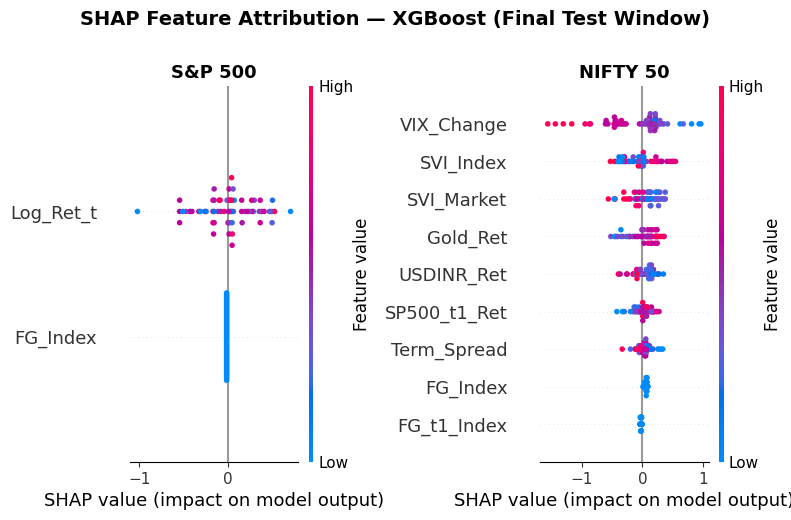

✅ SHAP beeswarm chart saved to data/plots/06_shap_beeswarm.png


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — SHAP beeswarm plots
# ─────────────────────────────────────────────────────────────────────────────
# What a beeswarm plot shows:
#   Each dot = one test observation.
#   X position = SHAP value (how much that feature pushed the prediction).
#   Color = feature value (red=high, blue=low).
#   Dots that spread far right = feature pushed strongly toward 'Up'.
#   Dots that spread far left  = feature pushed strongly toward 'Down'.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Feature Attribution — XGBoost (Final Test Window)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, shap_vals, X_test, feats, label in [
    (axes[0], shap_vals_sp500, X_test_sp500, feats_sp500, 'S&P 500'),
    (axes[1], shap_vals_nifty, X_test_nifty, feats_nifty, 'NIFTY 50'),
]:
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        X_test[feats],
        feature_names=feats,
        show=False,
        plot_type='dot',
        max_display=min(12, len(feats)),
        color_bar_label='Feature value'
    )
    ax.set_title(f'{label}', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(f'{PLOTS}/06_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP beeswarm chart saved to data/plots/06_shap_beeswarm.png')

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — H3 Test: is SVI more important in NIFTY 50 than S&P 500?
# ─────────────────────────────────────────────────────────────────────────────
# H3 Null hypothesis (H0): Mean |SHAP|(SVI, NIFTY) = Mean |SHAP|(SVI, S&P 500)
# H3 Alternative (H3)    : Mean |SHAP|(SVI, NIFTY) > Mean |SHAP|(SVI, S&P 500)
#
# Why we expect this:
#   India has proportionally higher retail investor participation than the US.
#   Retail investors respond to search trends more directly than institutions.
#   So when people in India google 'share market' or 'NIFTY' more than usual,
#   that attention is more likely to translate into actual market moves.
#   In the US, algorithms dominate and may dampen this retail attention effect.
# ─────────────────────────────────────────────────────────────────────────────

SVI_FEATURES = ['SVI_Market', 'SVI_Index']

def get_shap_for_features(shap_vals, feat_names, target_feats):
    """Extract per-observation mean |SHAP| for a subset of features."""
    idx = [i for i, f in enumerate(feat_names) if f in target_feats]
    if not idx:
        return np.array([])
    # Mean absolute SHAP across the target features for each observation
    return np.abs(shap_vals[:, idx]).mean(axis=1)

svi_shap_sp500 = get_shap_for_features(shap_vals_sp500, feats_sp500, SVI_FEATURES)
svi_shap_nifty = get_shap_for_features(shap_vals_nifty, feats_nifty, SVI_FEATURES)

print(f'SVI SHAP observations: S&P 500 = {len(svi_shap_sp500)} | NIFTY 50 = {len(svi_shap_nifty)}')
h3_result = {
    'Mean_SVI_SHAP_SP500': None,
    'Mean_SVI_SHAP_NIFTY': None,
    't_stat': None,
    'p_one_tail': None,
    'Reject_H0': False,
    'Spearman_r': None
}
if len(svi_shap_sp500) > 0 and len(svi_shap_nifty) > 0:
    # Two-sample t-test: is NIFTY SVI importance > S&P 500 SVI importance?
    t_stat, p_two = stats.ttest_ind(svi_shap_nifty, svi_shap_sp500, equal_var=False)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    print('\n' + '=' * 60)
    print('  H3 TEST — SVI more important in NIFTY 50 than S&P 500?')
    print('=' * 60)
    print(f'  Mean |SHAP|(SVI)  — S&P 500  : {svi_shap_sp500.mean():.6f}')
    print(f'  Mean |SHAP|(SVI)  — NIFTY 50 : {svi_shap_nifty.mean():.6f}')
    print(f'  Difference (NIFTY - S&P)     : {svi_shap_nifty.mean() - svi_shap_sp500.mean():+.6f}')
    print(f'  t-statistic                  : {t_stat:.4f}')
    print(f'  p-value (one-tail)           : {p_one:.4f}')
    print(f'  Reject H0 (α=0.05)           : {"✅ YES — SVI matters more in NIFTY 50" if p_one < ALPHA else "❌ NO — no significant difference"}')

    # Spearman rank correlation: how similar are the importance RANKINGS?
    # (Not just the values — the ordering of which features matter most)
    common = list(set(feats_sp500) & set(feats_nifty))
    if len(common) >= 3:
        rank_sp = shap_mean_sp500.reindex(common).rank(ascending=False)
        rank_ni = shap_mean_nifty.reindex(common).rank(ascending=False)
        sp_r, sp_p = stats.spearmanr(rank_sp, rank_ni)
        print()
        print(f'  Spearman rank correlation    : r = {sp_r:.3f}  (p = {sp_p:.4f})')
        if sp_r < 0.5:
            print('  Interpretation: HIGH divergence — markets use features very differently')
        elif sp_r < 0.75:
            print('  Interpretation: MODERATE divergence — some features matter differently')
        else:
            print('  Interpretation: LOW divergence — similar feature importance across markets')

    h3_result = {
        'Mean_SVI_SHAP_SP500' : round(float(svi_shap_sp500.mean()), 6),
        'Mean_SVI_SHAP_NIFTY' : round(float(svi_shap_nifty.mean()), 6),
        't_stat'              : round(float(t_stat), 4),
        'p_one_tail'          : round(float(p_one), 4),
        'Reject_H0'           : bool(p_one < ALPHA),
        'Spearman_r'          : round(float(sp_r), 3) if len(common) >= 3 else None
    }

SVI SHAP observations: S&P 500 = 0 | NIFTY 50 = 61


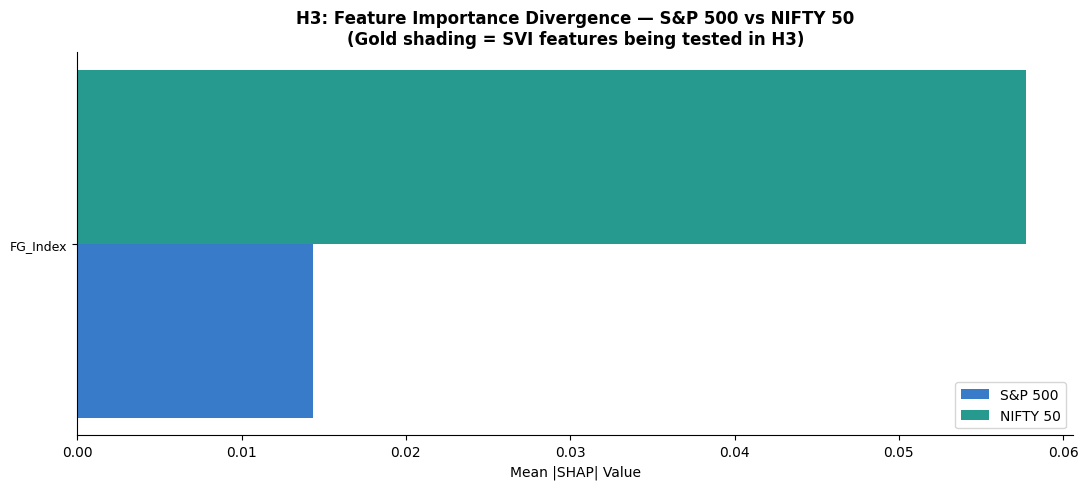

✅ Divergence chart saved to data/plots/06_shap_divergence.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Feature importance comparison chart (S&P 500 vs NIFTY 50)
# ─────────────────────────────────────────────────────────────────────────────

common_feats = list(set(feats_sp500) & set(feats_nifty))
if common_feats:
    # Sort by combined importance so the most important are at the top
    combined_imp = (
        shap_mean_sp500.reindex(common_feats).fillna(0) +
        shap_mean_nifty.reindex(common_feats).fillna(0)
    ).sort_values(ascending=True)
    common_sorted = combined_imp.index.tolist()

    fig, ax = plt.subplots(figsize=(11, max(5, len(common_sorted) * 0.48)))

    y      = np.arange(len(common_sorted))
    sp_val = shap_mean_sp500.reindex(common_sorted).fillna(0)
    ni_val = shap_mean_nifty.reindex(common_sorted).fillna(0)
    width  = 0.36

    bars_sp = ax.barh(y - width/2, sp_val, width, label='S&P 500', color='#1565C0', alpha=0.85)
    bars_ni = ax.barh(y + width/2, ni_val, width, label='NIFTY 50', color='#00897B', alpha=0.85)

    # Highlight SVI features with a gold background stripe
    for j, feat in enumerate(common_sorted):
        if feat in SVI_FEATURES:
            ax.axhspan(j - 0.48, j + 0.48, alpha=0.07, color='#F9A825')
            ax.text(
                max(sp_val.max(), ni_val.max()) * 1.02, j,
                'SVI ←', va='center', fontsize=8, color='#B8860B'
            )

    ax.set_yticks(y)
    ax.set_yticklabels(common_sorted, fontsize=9)
    ax.set_xlabel('Mean |SHAP| Value', fontsize=10)
    ax.set_title(
        'H3: Feature Importance Divergence — S&P 500 vs NIFTY 50\n'
        '(Gold shading = SVI features being tested in H3)',
        fontweight='bold', fontsize=12
    )
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{PLOTS}/06_shap_divergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Divergence chart saved to data/plots/06_shap_divergence.png')

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Transfer Degradation Protocol (H4)
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Train model on S&P 500 → test on S&P 500 → F1_local
#   Take that SAME model → apply to NIFTY 50 → F1_transfer
#   Transfer Loss Λ = F1_local - F1_transfer
#   Repeat in both directions: S&P→NIFTY and NIFTY→S&P
#
# Zero-shot means: no retraining. The exact weights from market A
# are applied directly to market B. This is how we measure portability.
#
# Feature alignment:
#   When moving from S&P to NIFTY, we can only use features that
#   BOTH markets have (no NIFTY-only features like USDINR_Ret or SP500_t1_Ret).
# ─────────────────────────────────────────────────────────────────────────────

def score_metrics(model, X, y):
    """Compute AUC, F1, Accuracy, MCC for a model on given data."""
    if len(np.unique(y)) < 2 or len(X) < 5:
        return {m: np.nan for m in ['AUC', 'F1', 'Accuracy', 'MCC']}
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return {
        'AUC'     : roc_auc_score(y, proba),
        'F1'      : f1_score(y, preds, zero_division=0),
        'Accuracy': accuracy_score(y, preds),
        'MCC'     : matthews_corrcoef(y, preds)
    }

def run_transfer_analysis(src_df, tgt_df, src_feats, tgt_feats,
                           src_windows, tgt_windows,
                           src_label, tgt_label):
    """
    Train on source market, test locally, then apply zero-shot to target market.
    Returns fold-level Transfer Loss results.
    """
    # Common features: exclude NIFTY-only cross-market lags
    common = [
        f for f in src_feats
        if f in tgt_df.columns and f not in NIFTY_EXTRA
    ]

    if not common:
        print(f'  No common features between {src_label} and {tgt_label}!')
        return pd.DataFrame()

    print(f'  Common features ({src_label}→{tgt_label}): {common}')

    records  = []
    n_folds  = min(len(src_windows), len(tgt_windows))

    for i in range(n_folds):
        src_tr, _, src_te = src_windows[i]
        tgt_tr, _, tgt_te = tgt_windows[i]

        for model_name, ModelClass, kwargs in [
            ('LogisticRegression', LogisticRegression,
             {'C': 1.0, 'max_iter': 1000, 'random_state': SEED}),
            ('RandomForest', RandomForestClassifier,
             {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 10,
              'random_state': SEED, 'n_jobs': -1}),
            ('XGBoost', xgb.XGBClassifier,
             {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
              'subsample': 0.8, 'colsample_bytree': 0.8,
              'eval_metric': 'logloss', 'random_state': SEED, 'verbosity': 0}),
        ]:
            try:
                X_src_tr = src_df.loc[src_tr, common].fillna(0)
                y_src_tr = src_df.loc[src_tr, TARGET]
                X_src_te = src_df.loc[src_te, common].fillna(0)
                y_src_te = src_df.loc[src_te, TARGET]
                X_tgt_te = tgt_df.loc[tgt_te, common].fillna(0)
                y_tgt_te = tgt_df.loc[tgt_te, TARGET]

                if len(X_src_tr) < 50:
                    continue

                # Scale for Logistic Regression
                if model_name == 'LogisticRegression':
                    scaler   = StandardScaler()
                    X_src_tr = pd.DataFrame(scaler.fit_transform(X_src_tr), columns=common)
                    X_src_te = pd.DataFrame(scaler.transform(X_src_te.values), columns=common)
                    X_tgt_te = pd.DataFrame(scaler.transform(X_tgt_te.values), columns=common)

                # Train model on SOURCE market
                model = ModelClass(**kwargs)
                model.fit(X_src_tr, y_src_tr)

                # Evaluate locally (source market)
                m_local    = score_metrics(model, X_src_te, y_src_te)
                # Evaluate zero-shot (target market)
                m_transfer = score_metrics(model, X_tgt_te, y_tgt_te)

                records.append({
                    'Direction'     : f'{src_label}→{tgt_label}',
                    'Fold'          : i + 1,
                    'Model'         : model_name,
                    'F1_local'      : m_local['F1'],
                    'F1_transfer'   : m_transfer['F1'],
                    'AUC_local'     : m_local['AUC'],
                    'AUC_transfer'  : m_transfer['AUC'],
                    'Lambda_F1'     : m_local['F1']  - m_transfer['F1'],
                    'Lambda_AUC'    : m_local['AUC'] - m_transfer['AUC'],
                })
            except Exception:
                pass

    return pd.DataFrame(records)

print('Running transfer degradation analysis...')
print('Direction 1: S&P 500 → NIFTY 50')
tr_sp_to_ni = run_transfer_analysis(
    sp500, nifty, selected_sp500, selected_nifty,
    windows_sp500, windows_nifty, 'S&P 500', 'NIFTY 50'
)

print('\nDirection 2: NIFTY 50 → S&P 500')
tr_ni_to_sp = run_transfer_analysis(
    nifty, sp500, selected_nifty, selected_sp500,
    windows_nifty, windows_sp500, 'NIFTY 50', 'S&P 500'
)

transfer_all = pd.concat([tr_sp_to_ni, tr_ni_to_sp], ignore_index=True)
print(f'\n✅ Transfer analysis complete. {len(transfer_all)} fold evaluations.')

Running transfer degradation analysis...
Direction 1: S&P 500 → NIFTY 50
  Common features (S&P 500→NIFTY 50): ['Log_Ret_t', 'FG_Index']

Direction 2: NIFTY 50 → S&P 500
  Common features (NIFTY 50→S&P 500): ['VIX_Change', 'Term_Spread', 'Gold_Ret', 'FG_Index', 'SVI_Market', 'SVI_Index']

✅ Transfer analysis complete. 90 fold evaluations.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — H4 Test: is Transfer Loss Λ significantly > 0?
# ─────────────────────────────────────────────────────────────────────────────
# H4 Null hypothesis (H0): F1_transfer = F1_local (no degradation)
# H4 Alternative (H4)    : F1_transfer < F1_local (model degrades when moved)
#
# Test: one-tailed paired t-test on fold-level Λ = F1_local - F1_transfer
# If Λ is significantly > 0, the model degrades — H4 supported.
# ─────────────────────────────────────────────────────────────────────────────

def h4_test(transfer_df, direction, model_name):
    """One-tailed t-test: is Transfer Loss Λ significantly positive?"""
    df = transfer_df[
        (transfer_df['Direction'] == direction) &
        (transfer_df['Model']     == model_name)
    ].dropna(subset=['Lambda_F1'])

    if len(df) < 3:
        return None

    t_stat, p_two = stats.ttest_1samp(df['Lambda_F1'], 0)
    # One-tailed: we predict Λ > 0 (degradation)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Direction'        : direction,
        'Model'            : model_name,
        'Folds'            : len(df),
        'Mean_F1_local'    : round(df['F1_local'].mean(), 4),
        'Mean_F1_transfer' : round(df['F1_transfer'].mean(), 4),
        'Mean_Lambda_F1'   : round(df['Lambda_F1'].mean(), 4),
        'Mean_Lambda_AUC'  : round(df['Lambda_AUC'].mean(), 4),
        't_stat'           : round(t_stat, 3),
        'p_one_tail'       : round(p_one, 4),
        'Reject_H0'        : p_one < ALPHA,
        'Result'           : '✅ Transfer loss confirmed' if p_one < ALPHA else '❌ No significant loss'
    }

h4_rows = []
for direction in ['S&P 500→NIFTY 50', 'NIFTY 50→S&P 500']:
    for model in ['LogisticRegression', 'RandomForest', 'XGBoost']:
        res = h4_test(transfer_all, direction, model)
        if res:
            h4_rows.append(res)

h4_df = pd.DataFrame(h4_rows)

print('=' * 70)
print('  H4 TEST RESULTS — Transfer Loss Λ = F1_local − F1_transfer')
print('=' * 70)
print(h4_df[[
    'Direction', 'Model', 'Mean_F1_local', 'Mean_F1_transfer',
    'Mean_Lambda_F1', 'p_one_tail', 'Result'
]].to_string(index=False))

  H4 TEST RESULTS — Transfer Loss Λ = F1_local − F1_transfer
       Direction              Model  Mean_F1_local  Mean_F1_transfer  Mean_Lambda_F1  p_one_tail                    Result
S&P 500→NIFTY 50 LogisticRegression         0.6838            0.6924         -0.0085      0.6693     ❌ No significant loss
S&P 500→NIFTY 50       RandomForest         0.6780            0.6866         -0.0087      0.6716     ❌ No significant loss
S&P 500→NIFTY 50            XGBoost         0.6138            0.6181         -0.0042      0.5872     ❌ No significant loss
NIFTY 50→S&P 500 LogisticRegression         0.6855            0.6442          0.0413      0.0344 ✅ Transfer loss confirmed
NIFTY 50→S&P 500       RandomForest         0.6783            0.6229          0.0554      0.0042 ✅ Transfer loss confirmed
NIFTY 50→S&P 500            XGBoost         0.6409            0.5903          0.0506      0.0085 ✅ Transfer loss confirmed


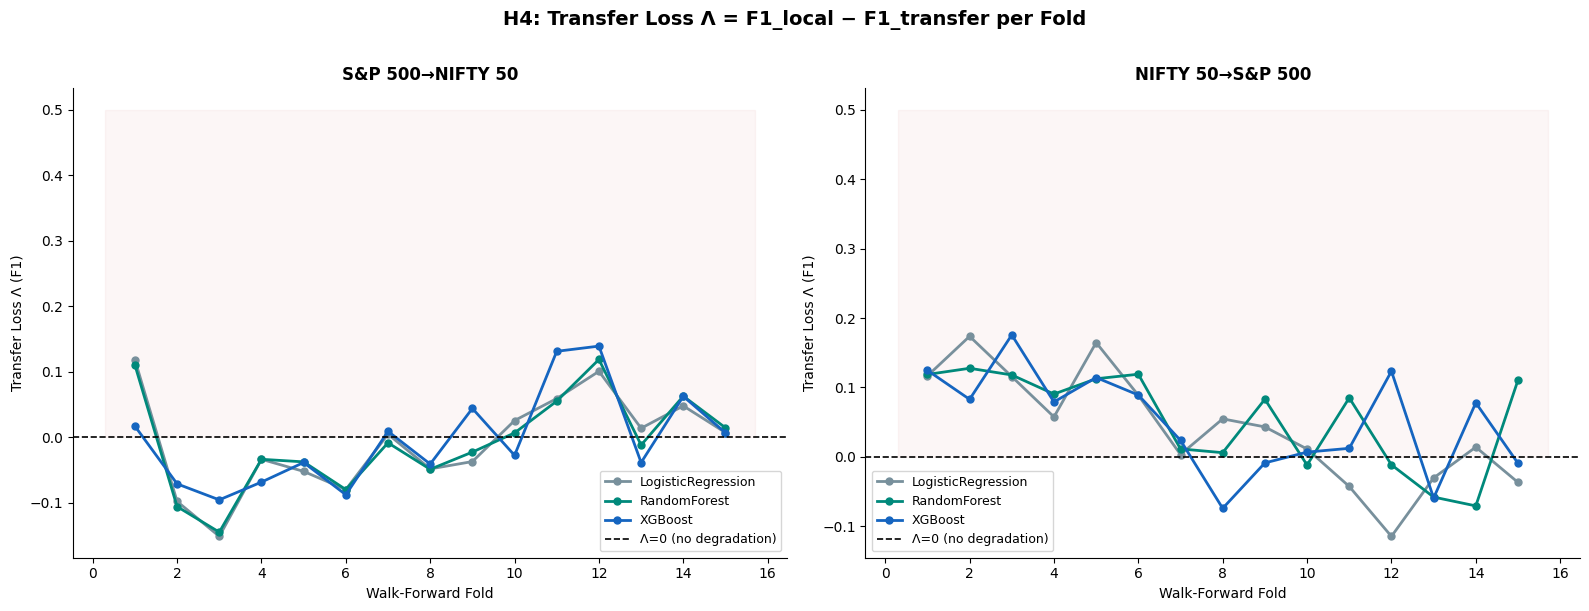

✅ Transfer loss chart saved to data/plots/06_transfer_loss.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Transfer Loss plot
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('H4: Transfer Loss Λ = F1_local − F1_transfer per Fold',
             fontsize=14, fontweight='bold', y=1.01)

model_colors = {
    'LogisticRegression': '#78909C',
    'RandomForest'      : '#00897B',
    'XGBoost'           : '#1565C0'
}

for ax, direction in zip(axes, ['S&P 500→NIFTY 50', 'NIFTY 50→S&P 500']):
    df_d = transfer_all[transfer_all['Direction'] == direction]

    for model, color in model_colors.items():
        sub = df_d[df_d['Model'] == model].dropna(subset=['Lambda_F1']).sort_values('Fold')
        if sub.empty:
            continue
        ax.plot(
            sub['Fold'], sub['Lambda_F1'],
            label=model, color=color, linewidth=2,
            marker='o', markersize=5
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Λ=0 (no degradation)')

    # Shade region above 0 (degradation zone)
    ax.fill_betweenx([0, 0.5], ax.get_xlim()[0], ax.get_xlim()[1],
                     alpha=0.04, color='#C62828')

    ax.set_xlabel('Walk-Forward Fold', fontsize=10)
    ax.set_ylabel('Transfer Loss Λ (F1)', fontsize=10)
    ax.set_title(f'{direction}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/06_transfer_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Transfer loss chart saved to data/plots/06_transfer_loss.png')

Transfer Degradation Attribution (S&P 500 model → NIFTY 50):

Feature              SHAP local  SHAP transfer     Delta  Interpretation
───────────────────────────────────────────────────────────────────────────
Log_Ret_t               0.22737        0.21607  +0.01130  ← caused degradation
FG_Index                0.02621        0.02424  +0.00198  ← caused degradation


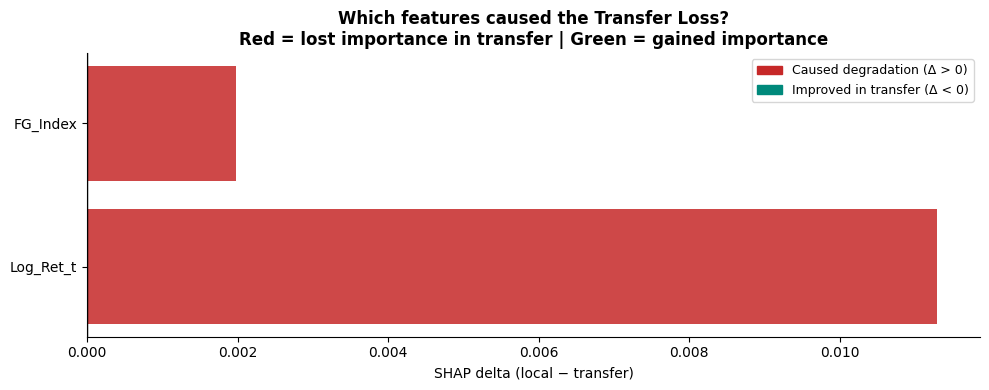


✅ Attribution chart saved to data/plots/06_shap_transfer_attribution.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — SHAP attribution: which features caused the Transfer Loss?
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Takes the S&P 500 model (trained on its home market).
#   Computes SHAP values when applied to S&P 500 test data (local).
#   Computes SHAP values when applied to NIFTY 50 test data (transfer).
#   The difference tells us WHICH features lost their importance when crossing markets.
#   Features with large positive SHAP_delta = they worked locally but failed in transfer.
# ─────────────────────────────────────────────────────────────────────────────

common_for_transfer = [
    f for f in selected_sp500
    if f in nifty.columns and f not in NIFTY_EXTRA
]

if common_for_transfer:
    # Re-train S&P 500 model on common features only
    tr_idx = windows_sp500[-1][0]
    te_sp  = windows_sp500[-1][2]
    te_ni  = windows_nifty[-1][2]

    X_sp_tr  = sp500.loc[tr_idx, common_for_transfer].fillna(0)
    y_sp_tr  = sp500.loc[tr_idx, TARGET]
    X_sp_te  = sp500.loc[te_sp, common_for_transfer].fillna(0)
    X_ni_te  = nifty.loc[te_ni, common_for_transfer].fillna(0)

    xgb_trans = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', random_state=SEED, verbosity=0
    )
    xgb_trans.fit(X_sp_tr, y_sp_tr)

    exp_trans   = shap.TreeExplainer(xgb_trans)
    shap_local  = exp_trans.shap_values(X_sp_te)
    shap_transf = exp_trans.shap_values(X_ni_te)

    shap_local_mean  = pd.Series(np.abs(shap_local).mean(axis=0),  index=common_for_transfer)
    shap_transf_mean = pd.Series(np.abs(shap_transf).mean(axis=0), index=common_for_transfer)

    attr_df = pd.DataFrame({
        'SHAP_local'   : shap_local_mean,
        'SHAP_transfer': shap_transf_mean,
        'SHAP_delta'   : shap_local_mean - shap_transf_mean,
    }).sort_values('SHAP_delta', ascending=False)

    print('Transfer Degradation Attribution (S&P 500 model → NIFTY 50):')
    print()
    print(f'{"Feature":18}  {"SHAP local":>11}  {"SHAP transfer":>13}  {"Delta":>8}  Interpretation')
    print('─' * 75)
    for feat, row in attr_df.iterrows():
        interp = '← caused degradation' if row['SHAP_delta'] > 0.0001 else '← improved in transfer' if row['SHAP_delta'] < -0.0001 else '  neutral'
        print(f'{feat:18}  {row["SHAP_local"]:11.5f}  {row["SHAP_transfer"]:13.5f}  {row["SHAP_delta"]:+8.5f}  {interp}')

    # Attribution bar chart
    fig, ax = plt.subplots(figsize=(10, max(4, len(attr_df) * 0.45)))
    colors = ['#C62828' if v > 0 else '#00897B' for v in attr_df['SHAP_delta']]
    ax.barh(attr_df.index, attr_df['SHAP_delta'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('SHAP delta (local − transfer)', fontsize=10)
    ax.set_title(
        'Which features caused the Transfer Loss?\n'
        'Red = lost importance in transfer | Green = gained importance',
        fontweight='bold', fontsize=12
    )
    red_p   = mpatches.Patch(color='#C62828', label='Caused degradation (Δ > 0)')
    green_p = mpatches.Patch(color='#00897B', label='Improved in transfer (Δ < 0)')
    ax.legend(handles=[red_p, green_p], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{PLOTS}/06_shap_transfer_attribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Attribution chart saved to data/plots/06_shap_transfer_attribution.png')

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Save all results and print final summary
# ─────────────────────────────────────────────────────────────────────────────

# Save hypothesis test results
pd.DataFrame([h3_result]).to_csv(f'{RESULTS}/h3_test_results.csv', index=False)
h4_df.to_csv(f'{RESULTS}/h4_test_results.csv',                      index=False)
transfer_all.to_csv(f'{RESULTS}/transfer_results.csv',               index=False)
attr_df.to_csv(f'{RESULTS}/shap_transfer_attribution.csv')

# Save SHAP importance tables
shap_mean_sp500.to_csv(f'{RESULTS}/shap_importance_sp500.csv', header=['mean_abs_shap'])
shap_mean_nifty.to_csv(f'{RESULTS}/shap_importance_nifty.csv', header=['mean_abs_shap'])

print('Files saved to data/results/:')
print('  ✅  h3_test_results.csv')
print('  ✅  h4_test_results.csv')
print('  ✅  transfer_results.csv')
print('  ✅  shap_transfer_attribution.csv')
print('  ✅  shap_importance_sp500.csv')
print('  ✅  shap_importance_nifty.csv')
print()

# ─────────────────────── FINAL RESULTS DASHBOARD ─────────────────────────────
h1_df = pd.read_csv(f'{RESULTS}/h1_test_results.csv')
h2_df = pd.read_csv(f'{SELECTED}/h2_test_results.csv')

print('=' * 70)
print('  QM640 CAPSTONE — ALL HYPOTHESIS RESULTS SUMMARY')
print('=' * 70)

print('\n── H1: Does alt-data beat baseline? (Diebold-Mariano AUC test) ──────')
for _, row in h1_df.iterrows():
    print(f"  {row.get('Market','?'):12} | {row.get('Model','?'):22} | "
          f"ΔAUC={row.get('Mean_Delta_AUC','?'):+.4f} | "
          f"p={row.get('p_one_tail','?'):.4f} | {row.get('Result','?')}")

print('\n── H2: Feature stability (Jaccard: alt-data vs technicals) ──────────')
for _, row in h2_df.iterrows():
    direction = '✅ Alt-data less stable' if row.get('Reject_H0') else '❌ No significant difference'
    print(f"  {row.get('Market','?'):12} | "
          f"J(alt)={row.get('Mean_Jaccard_AltData','?'):.3f} | "
          f"J(tech)={row.get('Mean_Jaccard_Tech','?'):.3f} | "
          f"p={row.get('p_one_tail','?'):.4f} | {direction}")

print('\n── H3: SVI structural divergence (SHAP t-test) ──────────────────────')
print(f"  SVI SHAP S&P 500: {h3_result['Mean_SVI_SHAP_SP500']:.6f}")
print(f"  SVI SHAP NIFTY  : {h3_result['Mean_SVI_SHAP_NIFTY']:.6f}")
print(f"  p-value         : {h3_result['p_one_tail']:.4f}")
print(f"  Result          : {'✅ SVI more important in NIFTY' if h3_result['Reject_H0'] else '❌ No significant difference'}")

print('\n── H4: Transfer Loss Λ = F1_local − F1_transfer ─────────────────────')
for _, row in h4_df.iterrows():
    print(f"  {str(row.get('Direction','?')):25} | {row.get('Model','?'):22} | "
          f"Λ(F1)={row.get('Mean_Lambda_F1','?'):+.4f} | "
          f"p={row.get('p_one_tail','?'):.4f} | {row.get('Result','?')}")

print()
print('─' * 70)
print('  🎉  PIPELINE COMPLETE — All 6 notebooks have been run successfully.')
print('  All results, charts, and data files are saved in your Google Drive:')
print('  /MyDrive/CapstoneDA/data/')
print('─' * 70)

Files saved to data/results/:
  ✅  h3_test_results.csv
  ✅  h4_test_results.csv
  ✅  transfer_results.csv
  ✅  shap_transfer_attribution.csv
  ✅  shap_importance_sp500.csv
  ✅  shap_importance_nifty.csv

  QM640 CAPSTONE — ALL HYPOTHESIS RESULTS SUMMARY

── H1: Does alt-data beat baseline? (Diebold-Mariano AUC test) ──────
  S&P 500      | LogisticRegression     | ΔAUC=+0.0000 | p=nan | ❌ No significant gain
  S&P 500      | RandomForest           | ΔAUC=-0.0030 | p=0.6706 | ❌ No significant gain
  S&P 500      | XGBoost                | ΔAUC=-0.0051 | p=0.7743 | ❌ No significant gain
  NIFTY 50     | LogisticRegression     | ΔAUC=+0.0163 | p=0.0345 | ✅ Alt-data helps
  NIFTY 50     | RandomForest           | ΔAUC=+0.0205 | p=0.0698 | ❌ No significant gain
  NIFTY 50     | XGBoost                | ΔAUC=-0.0025 | p=0.5736 | ❌ No significant gain

── H2: Feature stability (Jaccard: alt-data vs technicals) ──────────
  S&P 500      | J(alt)=0.571 | J(tech)=0.738 | p=0.2473 | ❌ No signific

TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
print("SP500 features:", feats_sp500)
print("NIFTY features:", feats_nifty)
print("SVI features found in SP500:", [f for f in feats_sp500 if f in SVI_FEATURES])
print("SVI features found in NIFTY:", [f for f in feats_nifty if f in SVI_FEATURES])